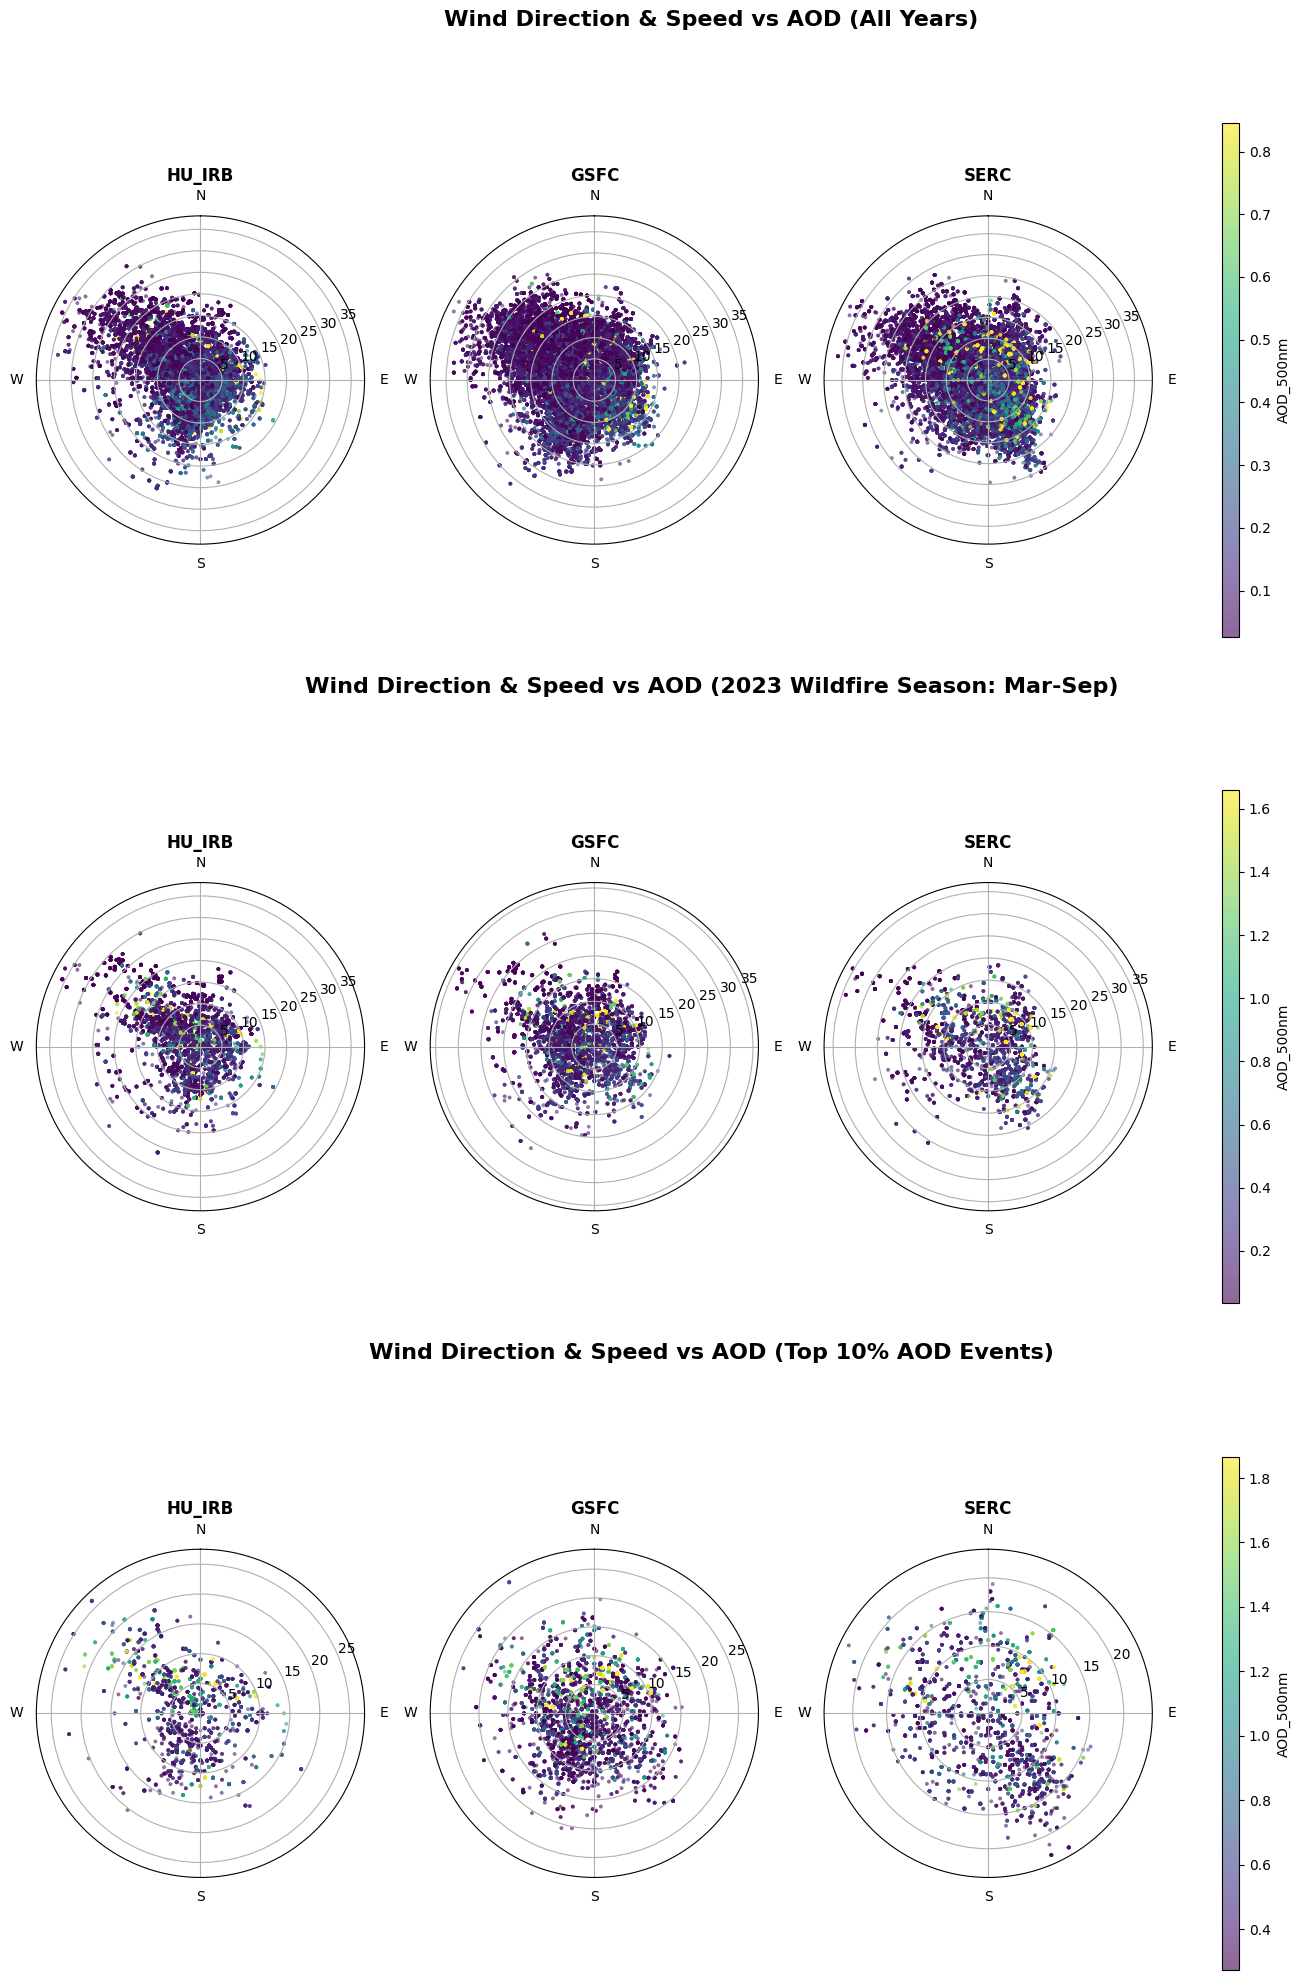

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sites = ["HU_IRB", "GSFC", "SERC"]
cols = ["datetime", "AOD_500nm", "wind_speed_10m", "wind_direction_10m"]

all_data = {}
for site in sites:
    df = pd.read_csv(f"../../data/merged_aod_metero_1/{site}_merged.csv",
                     parse_dates=["datetime"])[cols].dropna()
    all_data[site] = df

highlight_start = pd.Timestamp("2023-03-01")
highlight_end = pd.Timestamp("2023-09-30")

wildfire_data = {
    site: df[df["datetime"].between(highlight_start, highlight_end)]
    for site, df in all_data.items()
}

p90_data = {
    site: df[df["AOD_500nm"] >= df["AOD_500nm"].quantile(0.90)]
    for site, df in all_data.items()
}

datasets = [
    (all_data, "Wind Direction & Speed vs AOD (All Years)"),
    (wildfire_data, "Wind Direction & Speed vs AOD (2023 Wildfire Season: Mar-Sep)"),
    (p90_data, "Wind Direction & Speed vs AOD (Top 10% AOD Events)")
]

fig = plt.figure(figsize=(18, 20))
subfigs = fig.subfigures(3, 1, hspace=0)

for row_idx, (data_dict, row_title) in enumerate(datasets):
    subfig = subfigs[row_idx]
    subfig.suptitle(row_title, fontsize=16, fontweight="bold", y=1.05)
    
    all_aod_in_row = pd.concat([df["AOD_500nm"] for df in data_dict.values()])
    row_vmin = all_aod_in_row.quantile(0.02)
    row_vmax = all_aod_in_row.quantile(0.98)
    
    axes = subfig.subplots(1, 3, subplot_kw={"projection": "polar"})
    
    for col_idx, site in enumerate(sites):
        ax = axes[col_idx]
        df = data_dict[site]
        
        theta = np.deg2rad(df["wind_direction_10m"])
        r = df["wind_speed_10m"]
        aod = df["AOD_500nm"]

        sc = ax.scatter(theta, r, c=aod, cmap="viridis", vmin=row_vmin, vmax=row_vmax,
                        s=8, alpha=0.6, linewidths=0)
        
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_rlabel_position(67.5)
        ax.set_xticks(np.linspace(0, 2 * np.pi, 4, endpoint=False))
        ax.set_xticklabels(["N", "E", "S", "W"])
        ax.set_title(site, fontsize=12, fontweight="bold")
        
    cbar = subfig.colorbar(sc, ax=axes.ravel().tolist(), aspect=30)
    cbar.set_label("AOD_500nm", fontsize=10)
plt.savefig("../../data/wind1.png", dpi=300, bbox_inches="tight")
plt.show()

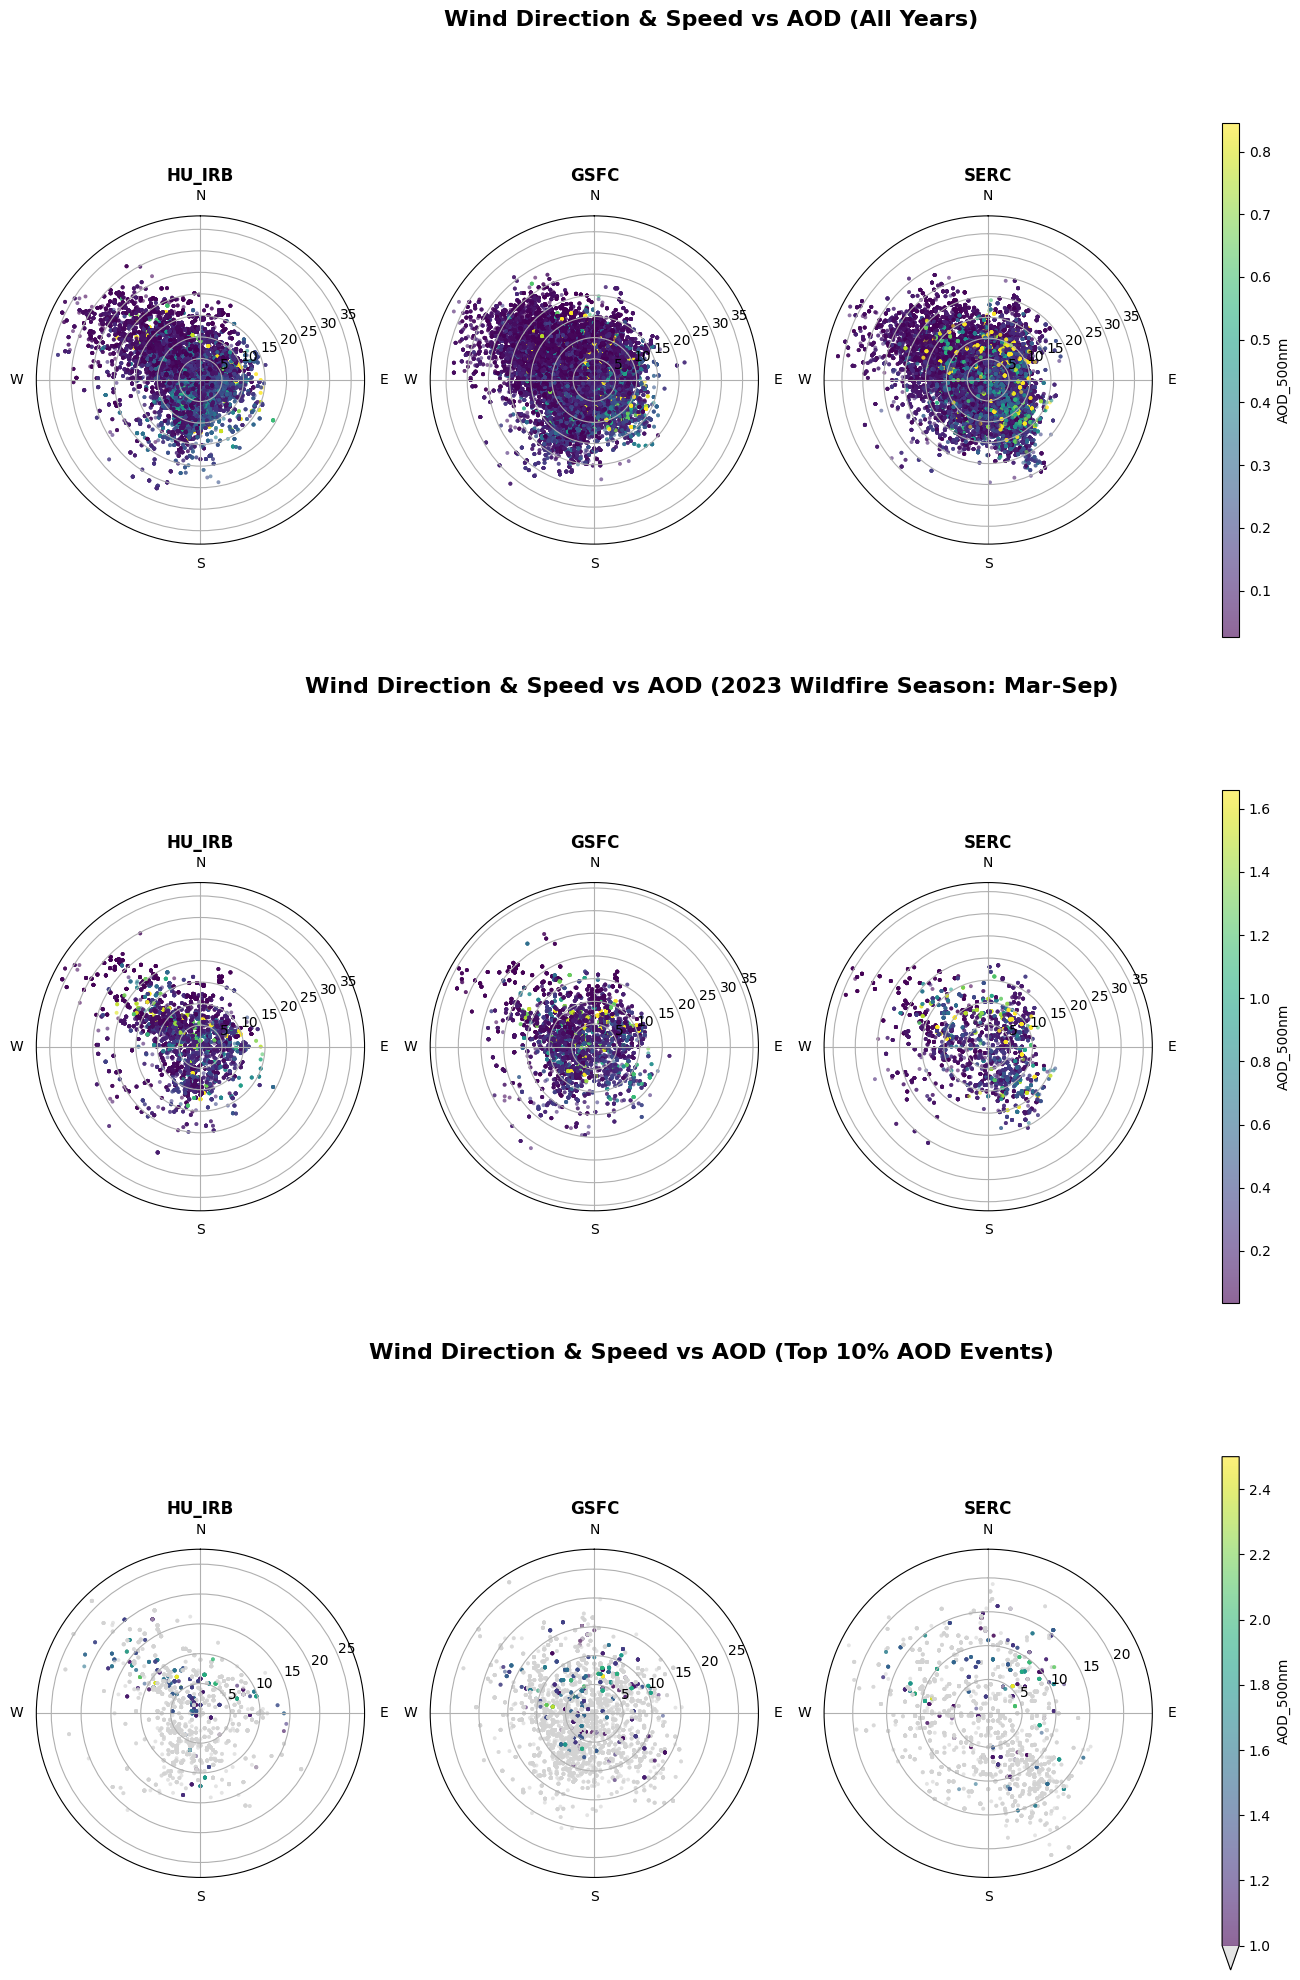

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sites = ["HU_IRB", "GSFC", "SERC"]
cols = ["datetime", "AOD_500nm", "wind_speed_10m", "wind_direction_10m"]

all_data = {}
for site in sites:
    df = pd.read_csv(f"../../data/merged_aod_metero_1/{site}_merged.csv",
                     parse_dates=["datetime"])[cols].dropna()
    all_data[site] = df

highlight_start = pd.Timestamp("2023-03-01")
highlight_end = pd.Timestamp("2023-09-30")

wildfire_data = {
    site: df[df["datetime"].between(highlight_start, highlight_end)]
    for site, df in all_data.items()
}

p90_data = {
    site: df[df["AOD_500nm"] >= df["AOD_500nm"].quantile(0.90)]
    for site, df in all_data.items()
}

datasets = [
    (all_data, "Wind Direction & Speed vs AOD (All Years)"),
    (wildfire_data, "Wind Direction & Speed vs AOD (2023 Wildfire Season: Mar-Sep)"),
    (p90_data, "Wind Direction & Speed vs AOD (Top 10% AOD Events)")
]

fig = plt.figure(figsize=(18, 20))
subfigs = fig.subfigures(3, 1, hspace=0)

for row_idx, (data_dict, row_title) in enumerate(datasets):
    subfig = subfigs[row_idx]
    subfig.suptitle(row_title, fontsize=16, fontweight="bold", y=1.05)
    
    all_aod_in_row = pd.concat([df["AOD_500nm"] for df in data_dict.values()])
    
    # Create a fresh copy of the colormap for each row to customize it safely
    cmap = plt.get_cmap("viridis").copy()
    
    if row_idx == 2:
        row_vmin = 1.0
        row_vmax = 2.5
        # Set all values below 1.0 to a muted light grey
        cmap.set_under("lightgrey")
        cbar_extend = 'min'
    else:
        row_vmin = all_aod_in_row.quantile(0.02)
        row_vmax = all_aod_in_row.quantile(0.98)
        cbar_extend = 'neither'
    
    axes = subfig.subplots(1, 3, subplot_kw={"projection": "polar"})
    
    for col_idx, site in enumerate(sites):
        ax = axes[col_idx]
        df = data_dict[site]
        
        theta = np.deg2rad(df["wind_direction_10m"])
        r = df["wind_speed_10m"]
        aod = df["AOD_500nm"]

        sc = ax.scatter(theta, r, c=aod, cmap=cmap, vmin=row_vmin, vmax=row_vmax,
                        s=8, alpha=0.6, linewidths=0)
        
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_rlabel_position(67.5)
        ax.set_xticks(np.linspace(0, 2 * np.pi, 4, endpoint=False))
        ax.set_xticklabels(["N", "E", "S", "W"])
        ax.set_title(site, fontsize=12, fontweight="bold")
        
    cbar = subfig.colorbar(sc, ax=axes.ravel().tolist(), aspect=30, extend=cbar_extend)
    cbar.set_label("AOD_500nm", fontsize=10)

plt.savefig("../../data/wind1_1.png", dpi=300, bbox_inches="tight")
plt.show()